<a href="https://colab.research.google.com/github/alameluramanathan79-source/Stock-Price-Prediction-ML/blob/main/stock_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [ ]:
from openpyxl import load_workbook

In [ ]:
data=pd.read_excel(r'/content/Minor Project Data set (Stock Price Prediction) (1).xlsx')

In [ ]:
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


In [ ]:
data.shape

(1009, 7)

In [ ]:
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1009 non-null   datetime64[ns]
 1   Open       1009 non-null   float64       
 2   High       1009 non-null   float64       
 3   Low        1009 non-null   float64       
 4   Close      1009 non-null   float64       
 5   Adj Close  1009 non-null   float64       
 6   Volume     1009 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 55.3 KB


In [ ]:
data.tail(5)

,Date,Open,High,Low,Close,Adj Close,Volume
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200
1008,2022-02-04,407.309998,412.769989,396.640015,410.170013,410.170013,7782400


In [ ]:
rolling_std_100 = data['Close'].rolling(window=100).std()
print(rolling_std_100.tail())

1004    73.063888
1005    74.463083
1006    76.377418
1007    78.753926
1008    80.897305
Name: Close, dtype: float64


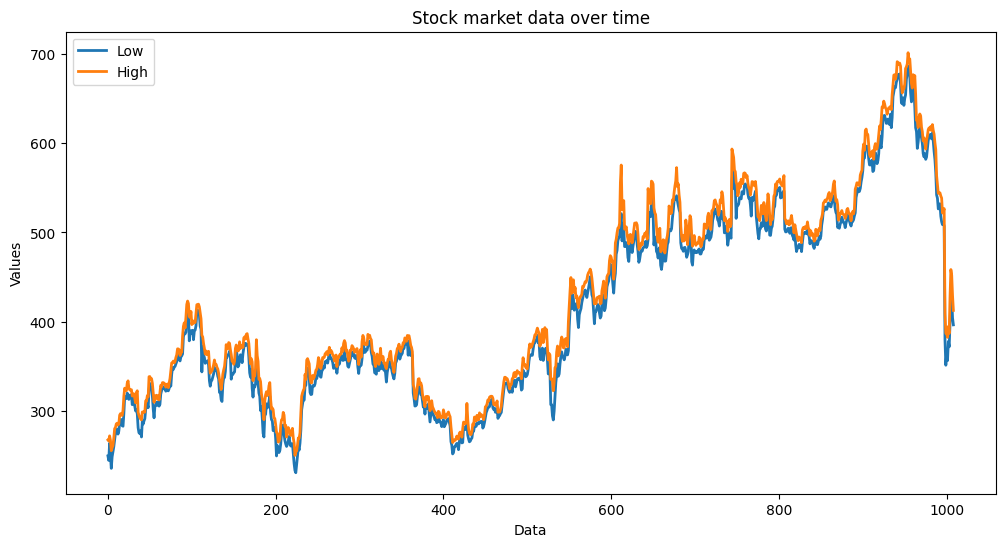

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(data['Low'],label='Low',linewidth=2)
plt.plot(data['High'],label='High',linewidth=2)
plt.xlabel('Data')
plt.ylabel('Values')
plt.title('Stock market data over time')
plt.legend()

In [ ]:
data.dtypes

Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume                int64
dtype: object

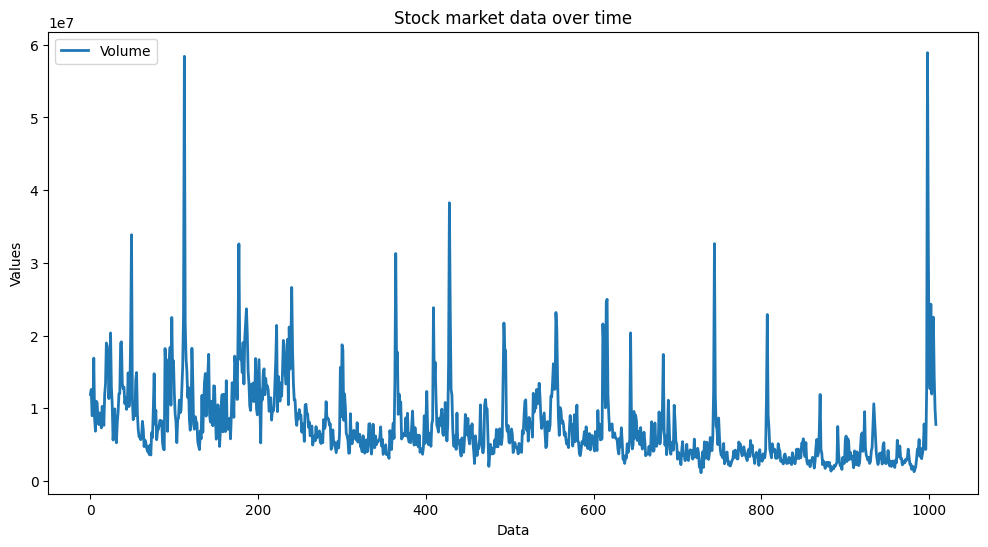

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(data['Volume'],label='Volume',linewidth=2)
plt.xlabel('Data')
plt.ylabel('Values')
plt.title('Stock market data over time')
plt.legend()

In [ ]:
data.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,1009,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1.009000e+03
mean,2020-02-05 07:30:58.870168320,419.059673,425.320703,412.374044,419.000733,419.000733,7.570685e+06
min,2018-02-05 00:00:00,233.919998,250.649994,231.229996,233.880005,233.880005,1.144000e+06
25%,2019-02-06 00:00:00,331.489990,336.299988,326.000000,331.619995,331.619995,4.091900e+06
50%,2020-02-06 00:00:00,377.769989,383.010010,370.880005,378.670013,378.670013,5.934500e+06
75%,2021-02-05 00:00:00,509.130005,515.630005,502.529999,509.079987,509.079987,9.322400e+06
max,2022-02-04 00:00:00,692.349976,700.989990,686.090027,691.690002,691.690002,5.890430e+07
std,NaN,108.537532,109.262960,107.555867,108.289999,108.289999,5.465535e+06


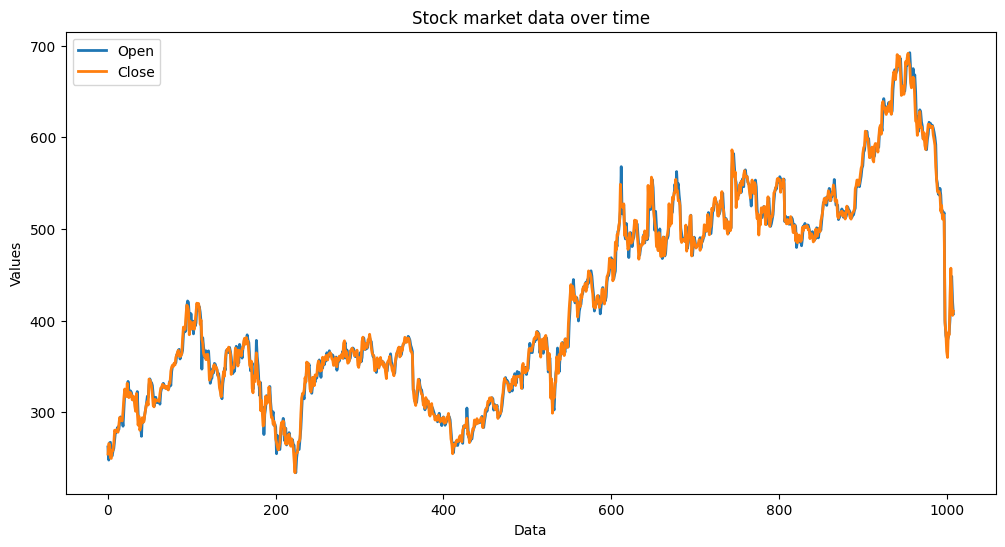

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(data['Open'],label='Open',linewidth=2)
plt.plot(data['Close'],label='Close',linewidth=2)
plt.xlabel('Data')
plt.ylabel('Values')
plt.title('Stock market data over time')
plt.legend()

In [ ]:
data.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [ ]:
rolling_std_100 = data['Close'].rolling(window=100).std()
print(rolling_std_100.tail())

1004    73.063888
1005    74.463083
1006    76.377418
1007    78.753926
1008    80.897305
Name: Close, dtype: float64


In [ ]:
daily_returns = data['Close'].pct_change()
print(daily_returns)

0            NaN
1       0.045072
2      -0.004366
3      -0.054657
4      -0.002519
          ...   
1004    0.111302
1005    0.070211
1006   -0.060486
1007   -0.055602
1008    0.011267
Name: Close, Length: 1009, dtype: float64


In [ ]:
cumulative_returns = (1 + daily_returns).cumprod() - 1
print(cumulative_returns)

0            NaN
1       0.045072
2       0.040510
3      -0.016361
4      -0.018839
          ...   
1004    0.679934
1005    0.797884
1006    0.689137
1007    0.595218
1008    0.613191
Name: Close, Length: 1009, dtype: float64


In [ ]:
rolling_average_100 = data['Close'].rolling(window=100).mean()
print(rolling_average_100.tail())

1004    600.807798
1005    599.403698
1006    597.711299
1007    595.874399
1008    594.198499
Name: Close, dtype: float64


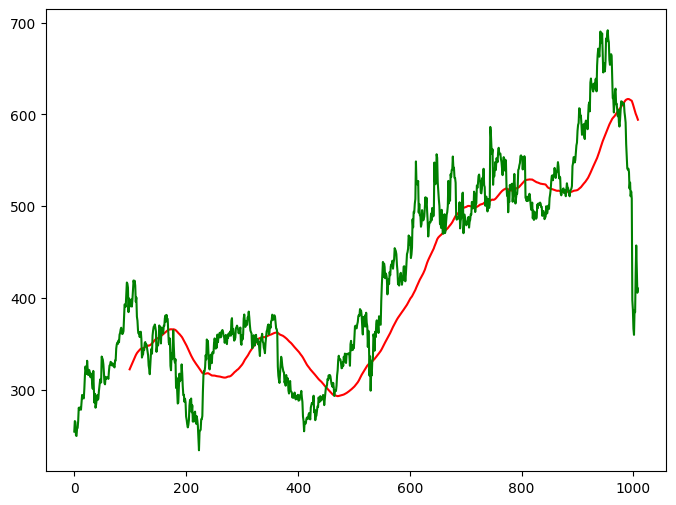

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(rolling_average_100,'r')
plt.plot(data.Close,'g')
plt.show()

In [ ]:
rolling_average_200=data['Close'].rolling(200).mean()
print(rolling_average_200.tail())

1004    560.237698
1005    559.751148
1006    559.150698
1007    558.634198
1008    558.141148
Name: Close, dtype: float64


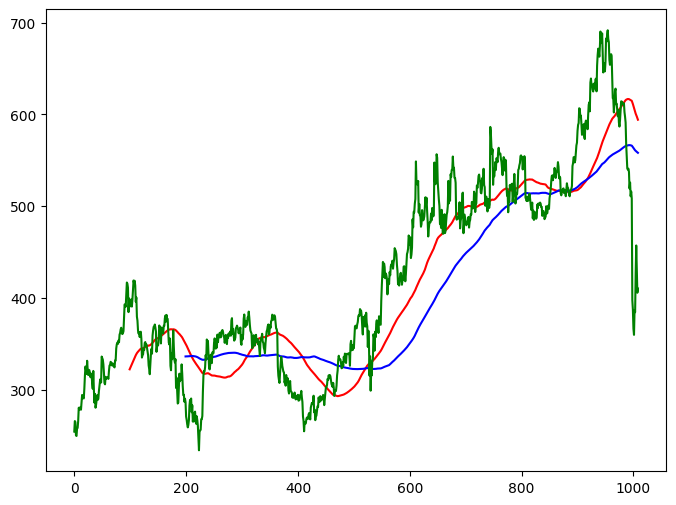

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(rolling_average_100,'r')
plt.plot(rolling_average_200,'b')
plt.plot(data.Close,'g')
plt.show()

In [ ]:
pd.set_option('display.float_format','{:.2f}'.format)

In [ ]:
data.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,1009,1009.00,1009.00,1009.00,1009.00,1009.00,1009.00
mean,2020-02-05 07:30:58.870168320,419.06,425.32,412.37,419.00,419.00,7570685.03
min,2018-02-05 00:00:00,233.92,250.65,231.23,233.88,233.88,1144000.00
25%,2019-02-06 00:00:00,331.49,336.30,326.00,331.62,331.62,4091900.00
50%,2020-02-06 00:00:00,377.77,383.01,370.88,378.67,378.67,5934500.00
75%,2021-02-05 00:00:00,509.13,515.63,502.53,509.08,509.08,9322400.00
max,2022-02-04 00:00:00,692.35,700.99,686.09,691.69,691.69,58904300.00
std,NaN,108.54,109.26,107.56,108.29,108.29,5465535.23


In [ ]:
openunique=data['Open'].unique()

In [ ]:
print(openunique,len(openunique))

[262.       247.699997 266.579987 267.079987 253.850006 252.139999
 257.290009 260.470001 270.029999 278.730011 277.73999  282.070007
 283.880005 281.       288.75     294.769989 293.100006 292.75
 284.649994 302.850006 319.880005 320.       322.200012 321.329987
 333.559998 323.869995 318.160004 323.170013 321.420013 315.799988
 313.26001  316.350006 313.070007 307.410004 309.359985 322.48999
 298.390015 287.       291.940002 285.450012 273.630005 293.149994
 289.100006 291.769989 297.679993 302.880005 309.720001 317.290009
 315.98999  329.660004 336.299988 332.880005 332.220001 329.149994
 319.220001 306.369995 310.       316.25     311.070007 310.359985
 311.649994 312.589996 308.709991 321.98999  325.899994 328.790009
 331.5      329.649994 327.25     325.940002 326.279999 327.529999
 324.899994 327.109985 334.049988 329.040009 344.339996 349.899994
 351.5      352.369995 353.799988 353.880005 362.679993 363.320007
 367.779999 368.540009 358.059998 361.880005 363.600006 367.529999


In [ ]:
rolling_mean = data['Close'].rolling(window=100).mean()
rolling_std = data['Close'].rolling(window=100).std()
upper_band = rolling_mean + (2 * rolling_std)
lower_band = rolling_mean - (2 * rolling_std)
print(upper_band)
print(lower_band)

0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
        ...  
1004   746.94
1005   748.33
1006   750.47
1007   753.38
1008   755.99
Name: Close, Length: 1009, dtype: float64
0         NaN
1         NaN
2         NaN
3         NaN
4         NaN
        ...  
1004   454.68
1005   450.48
1006   444.96
1007   438.37
1008   432.40
Name: Close, Length: 1009, dtype: float64


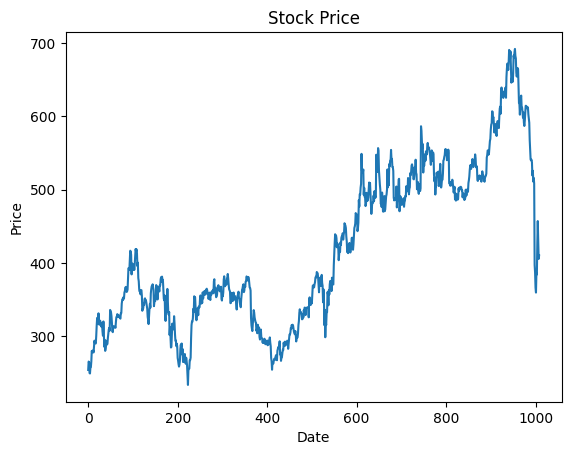

In [ ]:
import matplotlib.pyplot as plt
data['Close'].plot()
plt.title('Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

In [ ]:
highunique=data['High'].unique()

In [ ]:
print(highunique,len(highunique))

[267.899994 266.700012 272.450012 267.619995 255.800003 259.149994
 261.410004 269.880005 280.5      281.959991 285.809998 286.640015
 284.5      286.       295.649994 297.359985 295.75     295.25
 301.179993 316.910004 325.790009 323.73999  322.920013 331.440002
 333.980011 325.839996 323.880005 323.399994 324.109985 317.
 319.5      319.399994 314.119995 309.369995 321.029999 322.899994
 298.799988 295.350006 292.869995 291.25     290.309998 299.160004
 298.850006 299.549988 298.950012 311.640015 311.130005 317.48999
 316.100006 338.619995 338.820007 335.309998 336.51001  331.220001
 320.25     309.980011 316.630005 317.450012 317.880005 313.480011
 317.100006 312.589996 320.980011 329.019989 327.350006 331.950012
 332.059998 331.26001  330.5      326.940002 329.720001 330.450012
 326.420013 331.880005 336.630005 345.       354.       354.359985
 356.100006 355.529999 359.98999  363.       369.829987 369.679993
 368.700012 362.390015 365.670013 365.980011 384.25     395.029999
 398.8

In [ ]:
x = data[['Open', 'High', 'Low', 'Adj Close', 'Volume']]  # Use relevant features
y = data['Close']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
print("Shape of X_train:", x_train.shape)
print("Shape of X_test:", x_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (807, 5)
Shape of X_test: (202, 5)
Shape of y_train: (807,)
Shape of y_test: (202,)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()

In [ ]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
from sklearn.svm import SVR

In [ ]:
svr_model=SVR(kernel='rbf',C=100,epsilon=0.1)
svr_model.fit(x_train_scaled,y_train)
predictions=svr_model.predict(x_test_scaled)
mse=mean_squared_error(y_test,predictions)
print(predictions)
print("mean squared error:",mse)

[509.56878144 494.69565214 500.96440368 380.18052349 315.2568867
 476.19510488 495.8893352  299.96644266 359.21660946 328.25738042
 521.72020368 332.71516665 590.87843994 312.61324063 340.8400544
 547.91916139 532.51554925 612.2895789  351.1479794  391.38290388
 386.11932    366.37723291 269.24873343 354.26870411 436.16052507
 375.35989608 309.99609614 353.31720077 297.82233095 510.68438921
 565.85937629 512.7297654  411.06210346 338.38456299 510.38902604
 349.43113905 582.01631461 289.91855032 356.87077868 365.30365312
 353.10101553 349.92897319 343.34624028 613.63511232 370.36082977
 361.40653495 310.6987773  631.76701439 505.36951478 547.52329085
 495.55278337 522.42824086 313.17123943 488.78774955 421.52993
 564.92083952 308.97442958 306.90520577 331.79043389 317.52661287
 510.85585825 277.70033107 278.55159229 482.048201   515.88696201
 335.78881768 294.25627042 285.72709624 345.064607   630.03534847
 415.63012384 263.23639134 274.60862811 339.6292011  524.85550864
 368.96479363 3

In [ ]:
mse=mean_squared_error(y_test,predictions)
print("mean squared error:",mse)

mean squared error: 1.5221229360494137


In [ ]:
invalidData = data[data['High']<data['Low']]

In [ ]:
print(invalidData)

Empty DataFrame
Columns: [Date, Open, High, Low, Close, Adj Close, Volume]
Index: []


In [ ]:
columns = ['Open','High','Low','Volume']

In [ ]:
columns = ['Open','High','Low','Volume']

for column in columns:
  print(column)

  Q1 = data[column].quantile(0.25)
  Q3 = data[column].quantile(0.75)

  IQR = Q3-Q1

  print('Q1:',Q1,"\tQ3:",Q3,"\tIQR:",IQR)

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  print("lower:",lower_bound,"\tupper:",upper_bound)

  outliers = data[column].loc[(data[column] < lower_bound) | (data[column] > upper_bound)]

  print(len(outliers))
  validData = data.loc[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

  if(column == 'Open'):
    OpenFields = data.loc[(data['Open'] >= lower_bound) & (data['Open'] <= upper_bound)]

  print(len(validData))

  print("------------------------------------------")

print(OpenFields)

Open
Q1: 331.48999 	Q3: 509.130005 	IQR: 177.640015
lower: 65.02996749999994 	upper: 775.5900275
0
1009
------------------------------------------
High
Q1: 336.299988 	Q3: 515.630005 	IQR: 179.330017
lower: 67.30496249999999 	upper: 784.6250305
0
1009
------------------------------------------
Low
Q1: 326.0 	Q3: 502.529999 	IQR: 176.52999899999998
lower: 61.20500150000004 	upper: 767.3249974999999
0
1009
------------------------------------------
Volume
Q1: 4091900.0 	Q3: 9322400.0 	IQR: 5230500.0
lower: -3753850.0 	upper: 17168150.0
57
952
------------------------------------------
           Date   Open   High    Low  Close  Adj Close    Volume
0    2018-02-05 262.00 267.90 250.03 254.26     254.26  11896100
1    2018-02-06 247.70 266.70 245.00 265.72     265.72  12595800
2    2018-02-07 266.58 272.45 264.33 264.56     264.56   8981500
3    2018-02-08 267.08 267.62 250.00 250.10     250.10   9306700
4    2018-02-09 253.85 255.80 236.11 249.47     249.47  16906900
...         ...    .

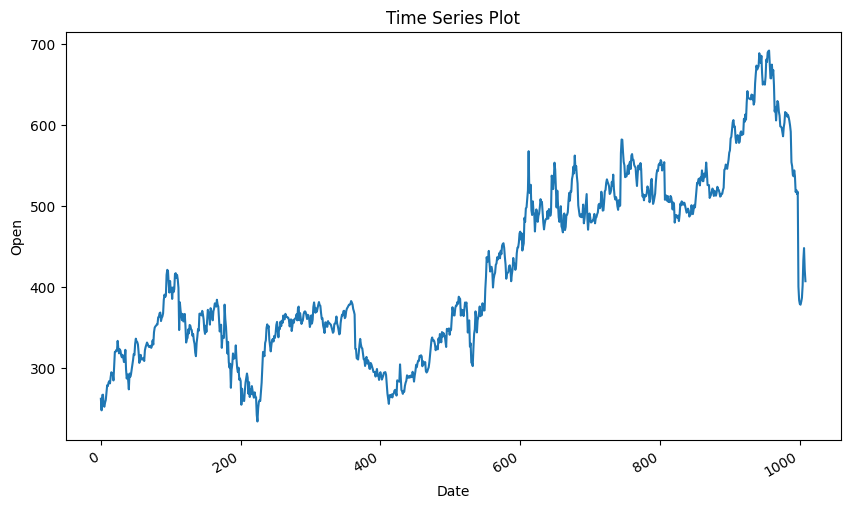

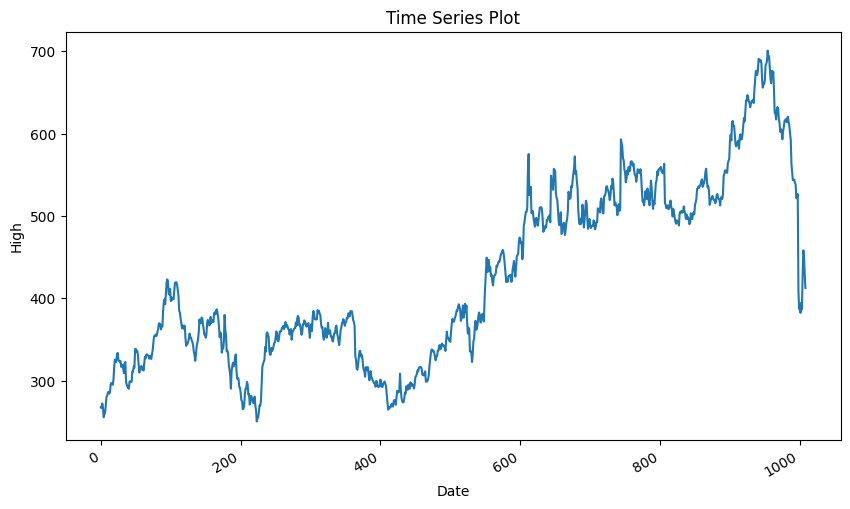

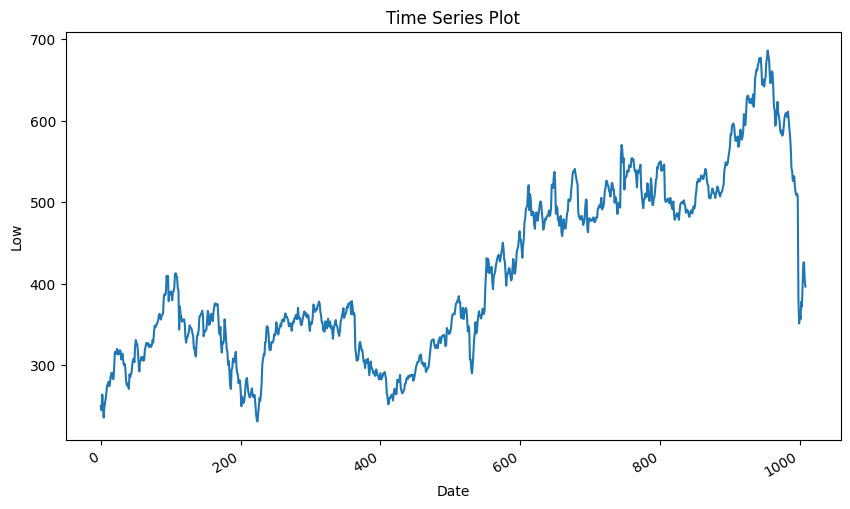

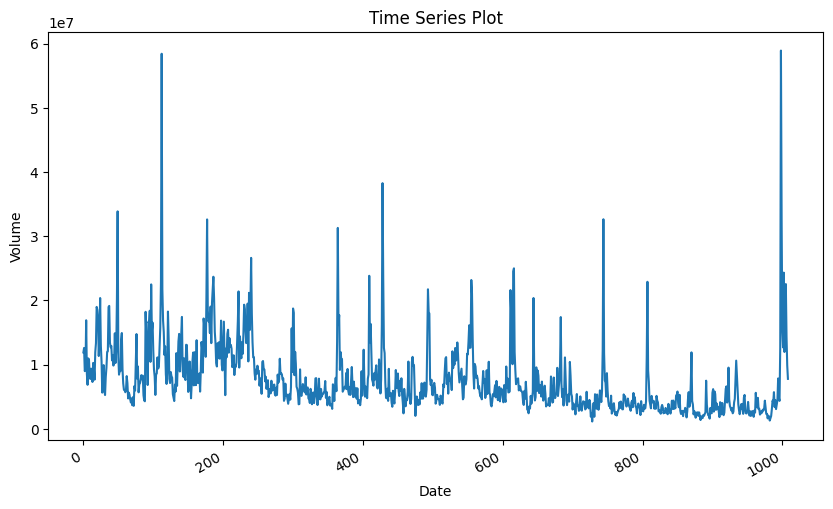

In [ ]:
columns = ['Open','High','Low','Volume']

for column in columns:

  fig, ax = plt.subplots(figsize=(10, 6))

  ax.plot(data.index, data[column])

  ax.set_xlabel('Date')
  ax.set_ylabel(column)
  ax.set_title('Time Series Plot')

  fig.autofmt_xdate()

  plt.show()

In [ ]:
data.corr()

,Date,Open,High,Low,Close,Adj Close,Volume
Date,1.00,0.84,0.84,0.84,0.84,0.84,-0.43
Open,0.84,1.00,1.00,1.00,1.00,1.00,-0.42
High,0.84,1.00,1.00,1.00,1.00,1.00,-0.40
Low,0.84,1.00,1.00,1.00,1.00,1.00,-0.43
Close,0.84,1.00,1.00,1.00,1.00,1.00,-0.41
Adj Close,0.84,1.00,1.00,1.00,1.00,1.00,-0.41
Volume,-0.43,-0.42,-0.40,-0.43,-0.41,-0.41,1.00


In [ ]:
mse=mean_squared_error(y_test,predictions)
print("mean squared error:",mse)

mean squared error: 1.5221229360494137


In [ ]:
from sklearn.metrics import r2_score

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
x_train_normalized=scaler.fit_transform(x_train)
x_test_normalized=scaler.transform(x_test)
param_grid={
    'kernel':['linear','rbf'],
    'C':[1,10,50,100],
    'epsilon':[0.01,0.1,0.2,0.5]
}
svr=SVR()
grid_search=GridSearchCV(svr,param_grid,cv=5,scoring='neg_mean_squared_error',n_jobs=-1)
grid_search.fit(x_train_normalized,y_train)
best_params=grid_search.best_params_
best_svr_model=SVR(**best_params)
best_svr_model.fit(x_train_normalized,y_train)
predictions=best_svr_model.predict(x_test_normalized)
mse=mean_squared_error(y_test,predictions)
print("Best hyperparameters:",best_params)
print("Mean_squared_error:",mse)

Best hyperparameters: {'C': 100, 'epsilon': 0.01, 'kernel': 'linear'}
Mean_squared_error: 0.0005993690268167737


In [ ]:
x=data[['Open','High','Low','Volume']].values

In [ ]:
y=data['Close'].values

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [ ]:

regressor=LinearRegression()

In [ ]:
model=regressor.fit(x_train,y_train)

In [ ]:
print(model.coef_)

[-6.08525352e-01  7.52637059e-01  8.57461003e-01  9.16527847e-08]


In [ ]:
print(model.intercept_)

-0.479062525175209


In [ ]:
y_pred=regressor.predict(x_test)

In [ ]:
predicted=regressor.predict(x_test)

In [ ]:
dframe=pd.DataFrame(y_test,predicted)

In [ ]:
dfr=pd.DataFrame({'Actual_Price':y_test,'Predicted_Price':predicted})

In [ ]:
print(dfr)

     Actual_Price  Predicted_Price
0          553.73           553.97
1          379.06           379.76
2          361.40           360.31
3          281.86           283.78
4          261.43           260.13
..            ...              ...
197        504.79           507.48
198        315.34           314.48
199        257.95           255.42
200        305.16           306.91
201        410.17           403.15

[202 rows x 2 columns]


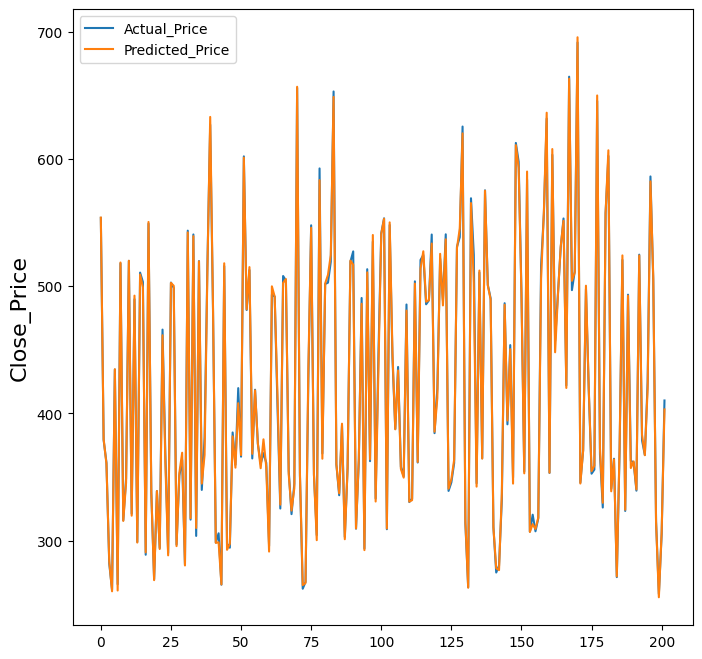

In [ ]:
plt.figure(figsize=(8,8))
plt.ylabel('Close_Price',fontsize=16)
plt.plot(dfr)
plt.legend(['Actual_Price','Predicted_Price'])
plt.show()

In [ ]:
r2=r2_score(y_test,predictions)
accuracy_percentage=r2*100
print("R-squared (accuracy) in percentage:",accuracy_percentage)

R-squared (accuracy) in percentage: -112.9322797094917
